Zadanie 5

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6776 - loss: 0.9641 - val_accuracy: 0.8111 - val_loss: 0.5621
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7924 - loss: 0.6051 - val_accuracy: 0.8307 - val_loss: 0.4827
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8217 - loss: 0.5190 - val_accuracy: 0.8477 - val_loss: 0.4387
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8360 - loss: 0.4731 - val_accuracy: 0.8537 - val_loss: 0.4127
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8442 - loss: 0.4444 - val_accuracy: 0.8601 - val_loss: 0.3939
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8519 - loss: 0.4208 - val_accuracy: 0.8652 - val_loss: 0.3847
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8583 - loss: 0.4035 - val_accuracy: 0.8687 - val_loss: 0.3722
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8610 - loss: 0.3907 - 

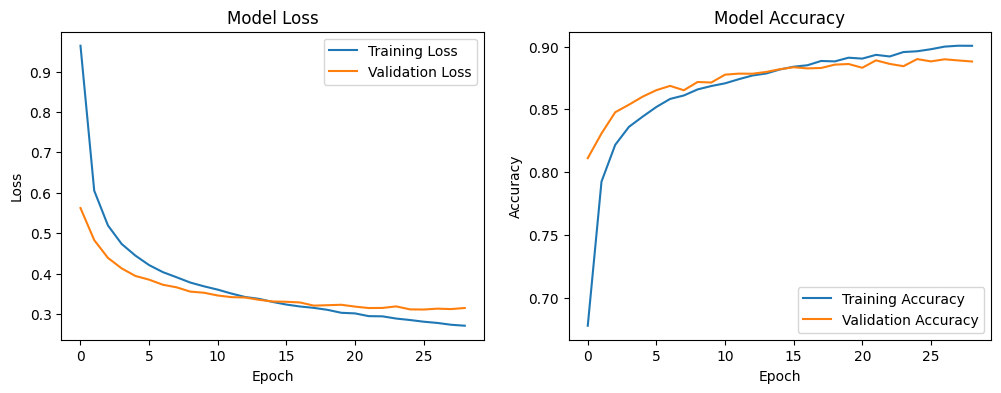

In [33]:
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping

(train_images, train_labels), (test_images, test_labels) = keras.datasets.fashion_mnist.load_data()

train_images = train_images / 255.0
test_images = test_images / 255.0

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2), 
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),              
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001), loss=keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=50, validation_split=0.2, callbacks=[early_stopping])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Zadanie 7

In [ ]:
import torch
import torch.nn as nn

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)
    
model = SimpleNN()
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params}') 

Total parameters: 109386


Zadanie 11

Architecture         Test Accuracy   Training Time (s) Number of Params    
(64,)                0.8689          19.03           50890               
(128, 64)            0.8671          23.17           109386              
(256, 128, 64)       0.8683          27.92           242762              
(512, 256, 128, 64)  0.8715          39.63           575050              


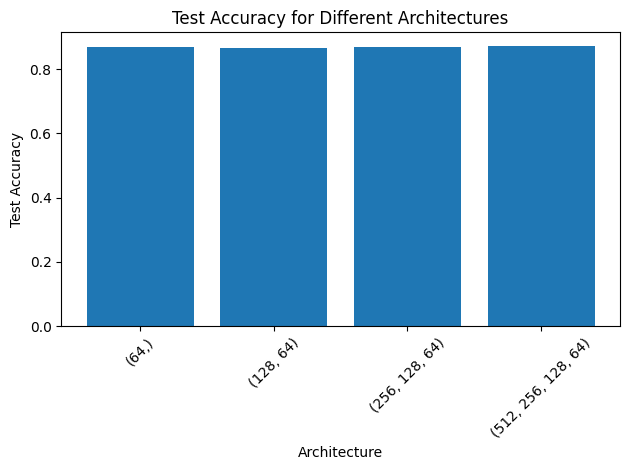

In [17]:
import time
from tensorflow import keras

(train_images, train_labels), (test_images, test_labels) = keras.datasets.fashion_mnist.load_data()

train_images = train_images / 255.0
test_images = test_images / 255.0

def create_model(architecture):
    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape=(28, 28)))
    for units in architecture:
        model.add(keras.layers.Dense(units, activation='relu'))
        model.add(keras.layers.Dropout(0.3))
    model.add(keras.layers.Dense(10, activation='softmax'))
    return model

architectures = [(64,), (128, 64), (256, 128, 64), (512, 256, 128, 64)]
results = []
for arch in architectures:
    model = create_model(arch)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    start_time = time.time()
    history = model.fit(train_images, train_labels, epochs=10, validation_split=0.2, verbose=0)
    end_time = time.time()
    test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=0)
    num_params = model.count_params()
    results.append((arch, test_accuracy, end_time - start_time, num_params))

print(f"{'Architecture':<20} {'Test Accuracy':<15} {'Training Time (s)':<15} {'Number of Params':<20}")
for arch, acc, time_taken, params in results:
    print(f"{str(arch):<20} {acc:<15.4f} {time_taken:<15.2f} {params:<20}")

architectures_str = [str(arch) for arch, _, _, _ in results]    
accuracies = [acc for _, acc, _, _ in results]
plt.bar(architectures_str, accuracies)
plt.title('Test Accuracy for Different Architectures')
plt.xlabel('Architecture')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
